# **FORECASTING SALES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/Walmart.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Aggregate to one network-wide weekly sales series
weekly_total = df.groupby('Date')['Weekly_Sales'].sum().sort_index()

We will be splitting our data into a test set and a train set to see how well our models perform with data not seen during training. Because we're working with time series data, we will not be using sklearn's built in train_test_split. Instead, we will be holding out the last 12 weeks of the dataset as the test set.

In [5]:
# Train/ test split 
train = weekly_total.iloc[:-12]
test = weekly_total.iloc[-12:]

print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} weeks)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} weeks)")

Train: 2010-02-05 to 2012-08-03 (131 weeks)
Test:  2012-08-10 to 2012-10-26 (12 weeks)


To set the benchmark for our sophisticated model, we will construct a naive model: predicting each test week's sale as the value of the same week exactly a year ago.

In [7]:
#naive model: predict each test week's sale as the value from the same week a year ago
naive_forecast = weekly_total.shift(52).iloc[-12:]

#using Mean Absolute Percentage Error to measure forecasting accuracy
mape_naive = (abs(test - naive_forecast) / test).mean() * 100
print(f"Naive seasonal baseline MAPE: {mape_naive:.2f}%")

#measuring RMSE to penalize large misses
rmse_naive = np.sqrt(((test - naive_forecast) ** 2).mean())
print(f"Naive baseline RMSE: ${rmse_naive:,.0f}")

Naive seasonal baseline MAPE: 2.12%
Naive baseline RMSE: $1,160,987


Our accuracy metric is Mean Aboslute Percentage Error (MAPE). Intuitively, we are interpreting: on average, the forecasting model missed by X%. RMSE of $1,160,987 means the typical miss was about $1,160,987 per week. Against the scale of around $45-48M total weekly sales, that is about 2.5%, consistent with our MAPE.

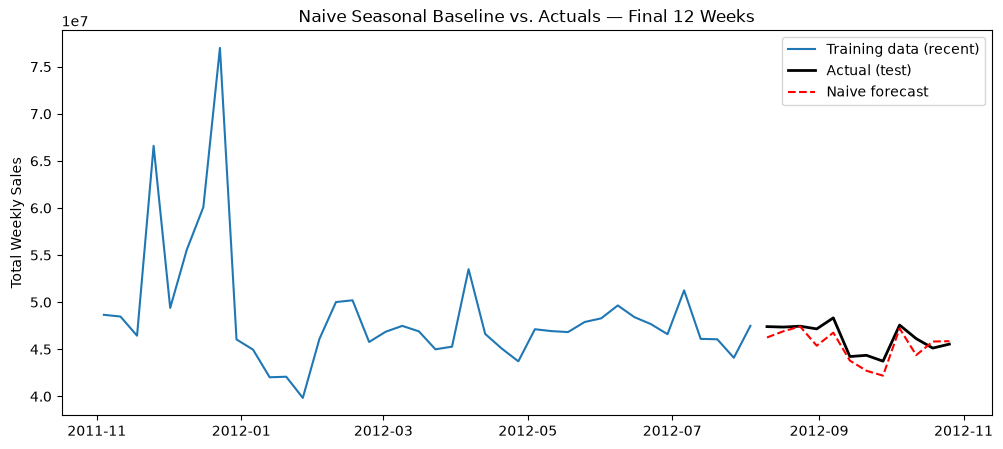

In [4]:
plt.figure(figsize=(12,5))
plt.plot(train.index[-40:], train.iloc[-40:], label='Training data (recent)')
plt.plot(test.index, test, label='Actual (test)', color='black', linewidth=2)
plt.plot(test.index, naive_forecast, label='Naive forecast', linestyle='--', color='red')
plt.title('Naive Seasonal Baseline vs. Actuals — Final 12 Weeks')
plt.ylabel('Total Weekly Sales')
plt.legend()
plt.show()

Unexpectedly, our naive model actually performs pretty well, with MAPE of 2.12% being a very strong baseline. This is because the dataset has very strong seasonality. To attempt constructing a model that outdoes the naive model, we will be running SARIMA, Seasonal Autoregressive Moving Average.

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA with weekly seasonality (period = 52)
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1), #q (AR) = d (differencing) = q (MA) = 1
    seasonal_order=(1, 1, 0, 52), #s = 52 for patterns repeating annually
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_forecast = sarima_model.forecast(steps=12)

mape_sarima = (abs(test - sarima_forecast) / test).mean() * 100
rmse_sarima = np.sqrt(((test - sarima_forecast) ** 2).mean())
print(f"SARIMA MAPE: {mape_sarima:.2f}%  |  RMSE: ${rmse_sarima:,.0f}")

/opt/anaconda3/envs/revenue-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/revenue-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


SARIMA MAPE: 1.65%  |  RMSE: $891,157


Our MAPE of 1.65% for the SARIMA beats the naive model's MAPE Of 2.12%. Let's visualize both models on the same graph to see the performance side by side.

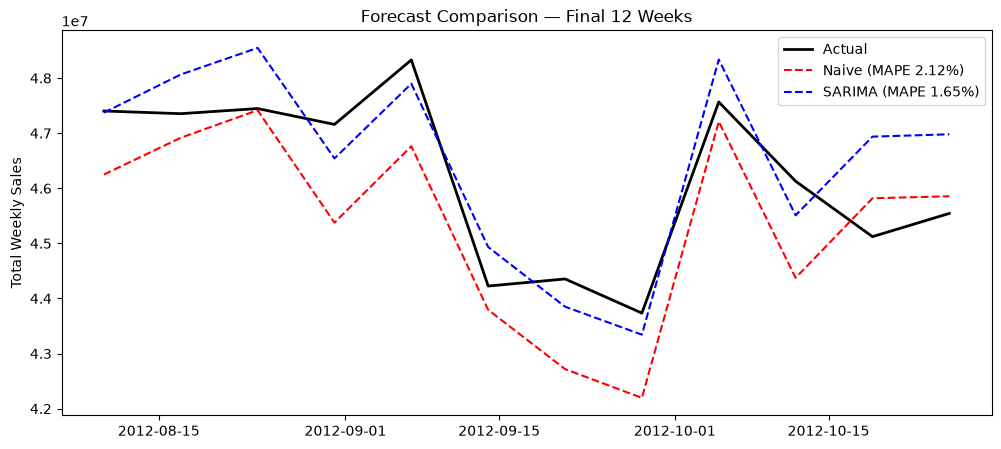

In [13]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label='Actual', color='black', linewidth=2)
plt.plot(test.index, naive_forecast, label='Naive (MAPE 2.12%)', linestyle='--', color='red')
plt.plot(test.index, sarima_forecast, label='SARIMA (MAPE 1.65%)', linestyle='--', color='blue')
plt.title('Forecast Comparison — Final 12 Weeks')
plt.ylabel('Total Weekly Sales')
plt.legend()
plt.show()

Visually, the SARIMA model matches the dips and peaks of the real data better than the naive model. This confirms what we observed in the MAPE comparison.

Now, let's move on to scenario stress-tests by applying validated pooled coefficient of Unemployment_Change from the earlier Sensitivity Analysis to specific adverse scenarios and quantify revenue changes.

In [ ]:
# Load the validated coefficient from Sensitivity Analysis
pooled_results = pd.read_csv('../data/pooled_model_results.csv', index_col=0)
unemp_coef = pooled_results.loc['Unemployment_Change', 'coefficient']
print(f"Validated unemployment coefficient: {unemp_coef:.4f}")

Validated unemployment coefficient: -0.2317


In [17]:
# Define adverse scenarios as different rises in total unemployment
scenarios = {
    'Baseline (no change)': 0.0,
    'Mild downturn (+0.5 pts)': 0.5,
    'Moderate downturn (+1.0 pts)': 1.0,
    'Severe downturn (+1.5 pts)': 1.5,
}

In [21]:
scenario_results = {}
for name, total_rise in scenarios.items():
    # Spread the total rise evenly across test weeks: weekly change = total / 12
    weekly_change = total_rise / 12
    # Each week's growth is hit by coef * weekly_change, compounding as unemployment keeps rising through the window
    adjustment = (1 + unemp_coef * weekly_change) ** np.arange(1, 13)
    scenario_results[name] = sarima_forecast.values * adjustment

scenario_df = pd.DataFrame(scenario_results, index=sarima_forecast.index)

# Total 12-week revenue under each scenario, and change vs baseline
totals = scenario_df.sum()
print(totals.apply(lambda x: f"${x/1e6:,.1f}M"))
print("\nRevenue at risk vs. baseline:")
for name in list(scenarios.keys())[1:]:
    delta = totals['Baseline (no change)'] - totals[name]
    print(f"  {name}: ${delta/1e6:,.1f}M")

Baseline (no change)            $558.3M
Mild downturn (+0.5 pts)        $524.7M
Moderate downturn (+1.0 pts)    $493.3M
Severe downturn (+1.5 pts)      $464.1M
dtype: str

Revenue at risk vs. baseline:
  Mild downturn (+0.5 pts): $33.6M
  Moderate downturn (+1.0 pts): $65.0M
  Severe downturn (+1.5 pts): $94.2M


The revenue-at-risk numbers show that an extremely severe economic shock where unemployment grows to 1.5pts can put up to $94.2M in revenue at risk across all stores. Let's visualize these adverse scenarios.

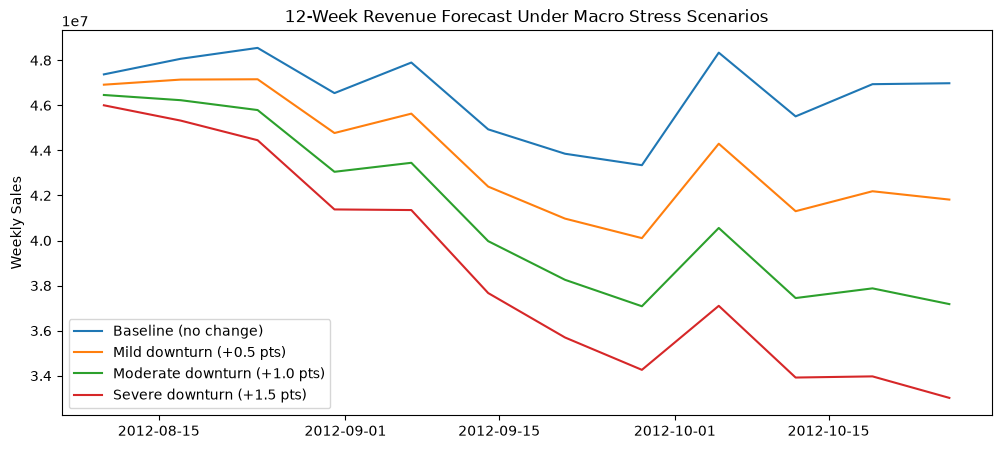

In [19]:
plt.figure(figsize=(12,5))
for col in scenario_df.columns:
    plt.plot(scenario_df.index, scenario_df[col], label=col)
plt.title('12-Week Revenue Forecast Under Macro Stress Scenarios')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

In [20]:
scenario_df.to_csv('../data/scenario_results.csv')